In [13]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
import os
import math
import glob
import re # Import re for natural_key
import gtsam
from matplotlib.patches import Ellipse
import gtsam.utils.plot as gtsam_plot

In [14]:
## Corner transformation and output limit calculation
def get_transformed_corners(img, H):
    h, w = img.shape[:2]
    corners = np.array([[0, 0], [w, 0], [w, h], [0, h]], dtype=np.float32).reshape(-1, 1, 2)
    transformed = cv2.perspectiveTransform(corners, H)
    return transformed.reshape(-1, 2)

## Compute output limits for all images
def compute_output_limits(images, homographies):
    all_corners = []
    for img, H in zip(images, homographies):
        corners = get_transformed_corners(img, H)
        all_corners.append(corners)
    
    all_corners = np.vstack(all_corners)
    x_min, y_min = np.floor(all_corners.min(axis=0)).astype(int)
    x_max, y_max = np.ceil(all_corners.max(axis=0)).astype(int)
    return x_min, y_min, x_max, y_max

In [15]:
## Define the paths to your datasets
DATA_6 = "6Images/" # Path for 6 images

# Helper for natural sorting of filenames
def natural_key(s):
    return [int(t) if t.isdigit() else t.lower() for t in re.split(r'(\d+)', os.path.basename(s))]

# Function to load images from a directory (including subfolders)
def load_images_from_folder(folder):
    images = []
    # Use glob to find all image files (e.g., .tif) in the folder and its subfolders
    image_extensions = ['*.tif']
    for ext in image_extensions:
        # Use natural_key for sorting
        images.extend(sorted(glob.glob(os.path.join(folder, '**', ext), recursive=True), key=natural_key))

    return images

# Load image paths
image_paths_6 = load_images_from_folder(DATA_6)
print(f"Found {len(image_paths_6)} images in {DATA_6}")

Found 6 images in 6Images/


In [16]:
## CLAHE for contrast enhancement
def apply_clahe(image):
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8, 8))
    if len(image.shape) == 3 and image.shape[2] == 3:
        lab = cv2.cvtColor(image, cv2.COLOR_BGR2LAB)
        l, a, b = cv2.split(lab)
        l_clahe = clahe.apply(l)
        lab_clahe = cv2.merge((l_clahe, a, b))
        enhanced_img = cv2.cvtColor(lab_clahe, cv2.COLOR_LAB2BGR)
    else:
        enhanced_img = clahe.apply(image)
    return enhanced_img

enhanced_images_6 = [apply_clahe(cv2.imread(img_path)) for img_path in image_paths_6]

Detected 2795 keypoints.
Detected 2809 keypoints.
Detected 2573 keypoints.
Detected 2379 keypoints.
Detected 2378 keypoints.
Detected 2632 keypoints.
Image 0 to 1: 287 good matches found.


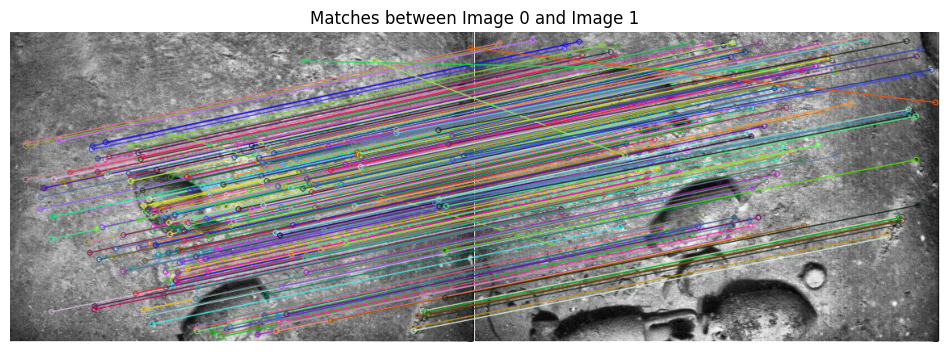

Image 1 to 2: 249 good matches found.


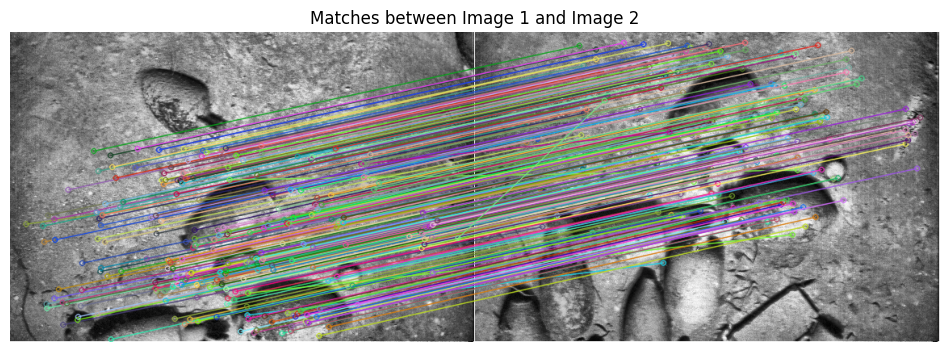

Image 2 to 3: 32 good matches found.


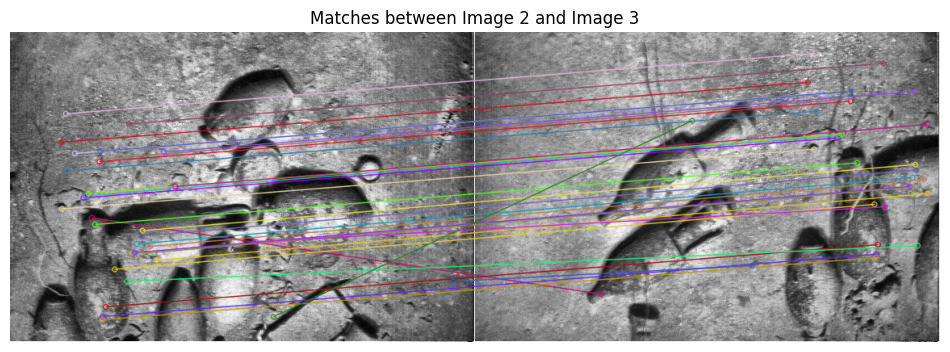

Image 3 to 4: 263 good matches found.


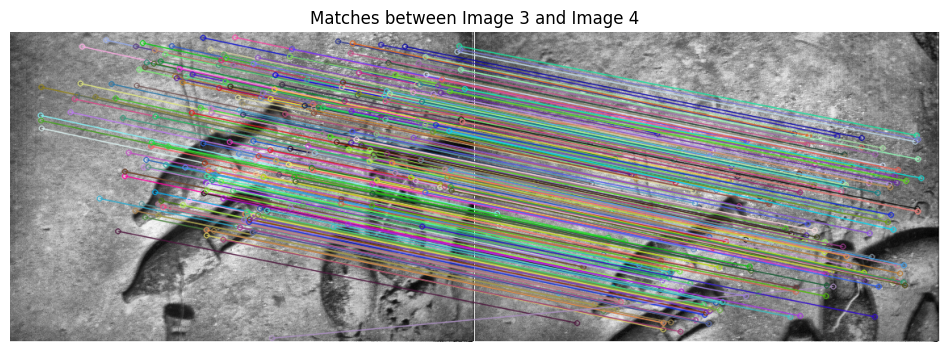

Image 4 to 5: 205 good matches found.


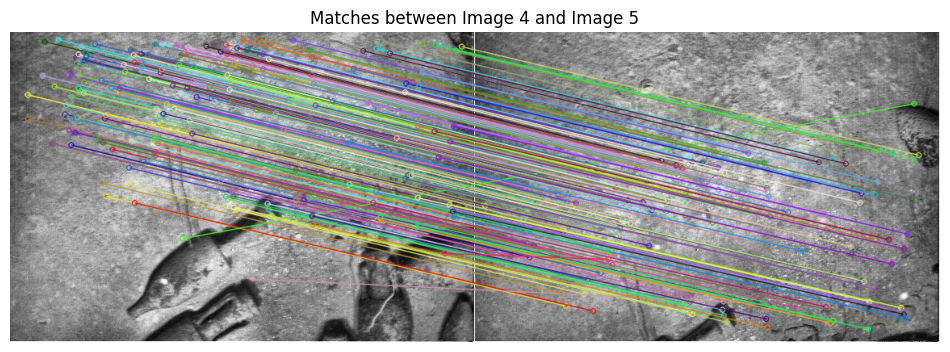

In [17]:
## Feature detection and matching using SIFT
sift = cv2.SIFT_create(nfeatures=5000)
bf = cv2.BFMatcher()
keypoints_list = []
descriptors_list = []
for img in enhanced_images_6:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    keypoints, descriptors = sift.detectAndCompute(gray, None)
    keypoints_list.append(keypoints)
    descriptors_list.append(descriptors)
    print(f"Detected {len(keypoints)} keypoints.")

# Match features between consecutive images
matches_list = []
for i in range(len(enhanced_images_6) - 1):
    matches = bf.knnMatch(descriptors_list[i], descriptors_list[i + 1], k=2)
    # Apply ratio test
    good_matches = []
    for m, n in matches:
        if m.distance < 0.75 * n.distance:
            good_matches.append(m)
    matches_list.append(good_matches)
    print(f"Image {i} to {i+1}: {len(good_matches)} good matches found.")
    # Draw matches for visualization
    img_matches = cv2.drawMatches(enhanced_images_6[i], keypoints_list[i],
                                  enhanced_images_6[i + 1], keypoints_list[i + 1],
                                  good_matches, None, flags=cv2.DrawMatchesFlags_NOT_DRAW_SINGLE_POINTS)
    plt.figure(figsize=(12, 6))
    plt.imshow(cv2.cvtColor(img_matches, cv2.COLOR_BGR2RGB))
    plt.title(f'Matches between Image {i} and Image {i+1}')
    plt.axis('off')
    plt.show()

In [18]:
## Estimate homographies using estimateAffinePartial2D and RANSAC
homographies = [np.eye(3)]  # First image's homography is identity
for i in range(len(matches_list)):
    src_pts = np.float32([keypoints_list[i][m.queryIdx].pt for m in matches_list[i]]).reshape(-1, 1, 2)
    dst_pts = np.float32([keypoints_list[i + 1][m.trainIdx].pt for m in matches_list[i]]).reshape(-1, 1, 2)
    
    # Estimate the 2x3 affine transformation matrix
    H, mask = cv2.estimateAffinePartial2D(src_pts, dst_pts, method=cv2.RANSAC)
    if H is not None:
        # Convert the 2x3 affine matrix to a 3x3 matrix for calculations
        H_3x3 = np.vstack([H, [0, 0, 1]])
        
        # Compute the inverse homography
        H_inv = np.linalg.inv(H_3x3)
        
        # Chain the homographies to get the cumulative transformation
        homographies.append(homographies[-1] @ H_inv)
    else:
        # If estimation fails, append the previous one to not break the chain
        homographies.append(homographies[-1])
        print(f"Homography estimation failed for Image {i} to {i+1}. Using previous.")

    print(f"Cumulative homography for Image {i+1} estimated.")

Cumulative homography for Image 1 estimated.
Cumulative homography for Image 2 estimated.
Cumulative homography for Image 3 estimated.
Cumulative homography for Image 4 estimated.
Cumulative homography for Image 5 estimated.


In [19]:
## Compute output limits
x_min, y_min, x_max, y_max = compute_output_limits(enhanced_images_6, homographies)
print(f"Output limits: x_min={x_min}, y_min={y_min}, x_max={x_max}, y_max={y_max}")
output_width = x_max - x_min
output_height = y_max - y_min
print(f"Output size: width={output_width}, height={output_height}")
# Offset to shift images to positive coordinates
offset_x = -x_min
offset_y = -y_min
offset = np.array([[1, 0, offset_x], [0, 1, offset_y], [0, 0, 1]])
print(f"Offset: x={offset_x}, y={offset_y}")
# Adjust homographies with offset
adjusted_homographies = [offset @ H for H in homographies]

## Initialize panorama canvas
panorama_6 = np.zeros((output_height, output_width, 3), dtype=np.uint8)


Output limits: x_min=-380, y_min=0, x_max=576, y_max=713
Output size: width=956, height=713
Offset: x=380, y=0


In [20]:
## Warp and blend each image into the panorama
for i in range(len(enhanced_images_6)):
    warped_img = cv2.warpPerspective(enhanced_images_6[i], adjusted_homographies[i], (output_width, output_height))
    mask = cv2.cvtColor(warped_img, cv2.COLOR_BGR2GRAY)
    mask = (mask > 0).astype(np.uint8) * 255
    panorama_6 = cv2.bitwise_and(panorama_6, panorama_6, mask=cv2.bitwise_not(mask))
    panorama_6 = cv2.add(panorama_6, warped_img)
print("Image stitching completed.")

Image stitching completed.


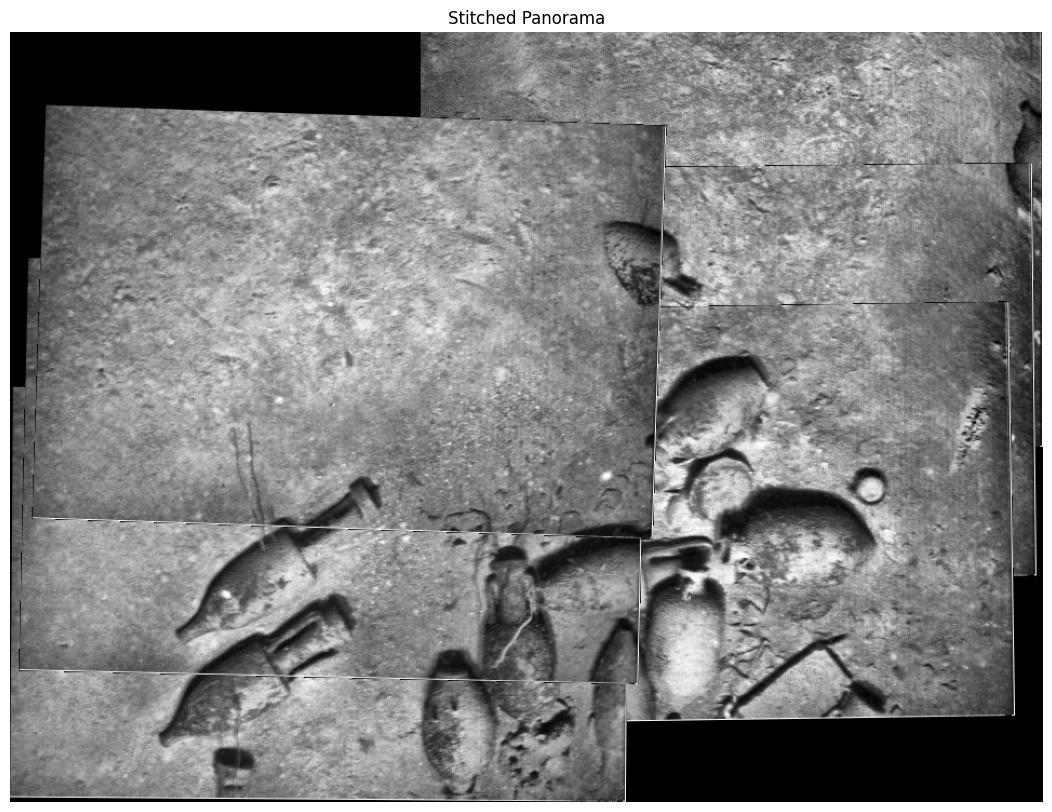

In [21]:
## Display the final panorama
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(panorama_6, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Stitched Panorama')
plt.show()

In [22]:
## Create a factor graph
graph = gtsam.NonlinearFactorGraph()
initial_estimate = gtsam.Values()

In [23]:
## Estimate camera poses by calculating the centers of the images
def extract_pose_from_homography(H):
    # The simpler, standard method we used before
    H_norm = H / H[2, 2]
    x = H_norm[0, 2]
    y = H_norm[1, 2]
    theta = math.atan2(H_norm[1, 0], H_norm[0, 0])
    return gtsam.Pose2(x, y, theta)

camera_poses = [extract_pose_from_homography(H) for H in homographies]

In [24]:
## Add prior on the first pose
prior_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.1, 0.1, 0.1]))
graph = gtsam.NonlinearFactorGraph()
initial_estimate = gtsam.Values()
graph.add(gtsam.PriorFactorPose2(0, camera_poses[0], prior_noise))
initial_estimate.insert(0, camera_poses[0])
print("Added prior on the first pose for Dataset 6.")

Added prior on the first pose for Dataset 6.


In [25]:
## Add odometry factors between consecutive poses
odometry_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.5, 0.5, 0.1]))
for i in range(1, len(camera_poses)):
    odometry = camera_poses[i - 1].between(camera_poses[i])
    graph.add(gtsam.BetweenFactorPose2(i - 1, i, odometry, odometry_noise))
    initial_estimate.insert(i, camera_poses[i])
print("Added odometry factors for Dataset 6.")

Added odometry factors for Dataset 6.


In [26]:
## Store a copy of the pre-optimization graph and initial estimate
graph_pre = gtsam.NonlinearFactorGraph(graph)  
initial_estimate_pre = gtsam.Values(initial_estimate)

In [27]:
## Add loop closure factors based on feature matches
loop_closure_noise = gtsam.noiseModel.Diagonal.Sigmas(np.array([0.25, 0.25, 0.05]))
connections = [] # For plotting later
Nimages_6 = len(image_paths_6)

for i in range(Nimages_6):
    # Odometry is already added, so skip adjacent pairs (j=i+1)
    for j in range(i + 2, Nimages_6):
        matches = bf.knnMatch(descriptors_list[i], descriptors_list[j], k=2)
        good = [m for m, n in matches if m.distance < 0.75 * n.distance]
        
        if len(good) > 50:  # Threshold for considering loop closure
            # Extract matched keypoints
            src = np.float32([keypoints_list[i][m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
            dst = np.float32([keypoints_list[j][m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
            
            # This H maps points from j to i
            H_rel, mask = cv2.findHomography(dst, src, cv2.RANSAC, 5.0)
            
            num_inliers = np.sum(mask)
            if H_rel is not None and num_inliers > 30:
                relative_pose = extract_pose_from_homography(H_rel)
                graph.add(gtsam.BetweenFactorPose2(i, j, relative_pose, loop_closure_noise))
                connections.append((i, j))
                print(f"Added loop closure between images {i} and {j} with {num_inliers} inliers.")
print("Added loop closure factors for Dataset 6.")
print(f"Total loop closures added: {len(connections)}")

Added loop closure between images 0 and 2 with 43 inliers.
Added loop closure factors for Dataset 6.
Total loop closures added: 1


In [28]:
## Optimize the factor graph
params = gtsam.LevenbergMarquardtParams()
params.setVerbosityLM("SUMMARY")
optimizer = gtsam.LevenbergMarquardtOptimizer(graph, initial_estimate, params)
result = optimizer.optimize()
print("Optimization complete for Dataset 6.")

Optimization complete for Dataset 6.
Initial error: 46.2939, values: 6
iter      cost      cost_change    lambda  success iter_time
   0      4.88862           41      1e-05      1          0
   1          4.9        0.014      1e-06      1          0
   2          4.9      4.2e-06      1e-07      1          0


In [29]:
## Extract optimized poses
def pose_2_homography(pose):
    x, y, theta = pose.x(), pose.y(), pose.theta()
    cos_theta = math.cos(theta)
    sin_theta = math.sin(theta)
    H = np.array([[cos_theta, -sin_theta, x],
                  [sin_theta,  cos_theta, y],
                  [0,          0,         1]])
    return H
optimized_homographies = [pose_2_homography(result.atPose2(i)) for i in range(Nimages_6)]
print("Converted optimized poses to homographies for Dataset 6.")

Converted optimized poses to homographies for Dataset 6.


In [30]:
## Stitch images using optimized homographies
x_min, y_min, x_max, y_max = compute_output_limits(enhanced_images_6, optimized_homographies)
print(f"Output limits after optimization: x_min={x_min}, y_min={y_min}, x_max={x_max}, y_max={y_max}")
output_width = x_max - x_min
output_height = y_max - y_min
print(f"Output size after optimization: width={output_width}, height={output_height}")
translation = np.array([[1, 0, -x_min],
                        [0, 1, -y_min],
                        [0, 0, 1]])
adjusted_optimized_homographies = [translation @ H for H in optimized_homographies]
panorama_optimized = np.zeros((output_height, output_width, 3), dtype=np.uint8)
for i in range(len(enhanced_images_6)):
    warped_img = cv2.warpPerspective(enhanced_images_6[i], adjusted_optimized_homographies[i], (output_width, output_height))
    if len(warped_img.shape) == 3 and warped_img.shape[2] == 3:
        mask = cv2.cvtColor(warped_img, cv2.COLOR_BGR2GRAY) > 0
        panorama_optimized[mask] = warped_img[mask]
    else:
        mask = warped_img > 0
        warped_img_bgr = cv2.cvtColor(warped_img, cv2.COLOR_GRAY2BGR)
        panorama_optimized[mask] = warped_img_bgr[mask]
print("Image stitching with optimized homographies completed for Dataset 6.")

Output limits after optimization: x_min=-378, y_min=-1, x_max=576, y_max=720
Output size after optimization: width=954, height=721
Image stitching with optimized homographies completed for Dataset 6.


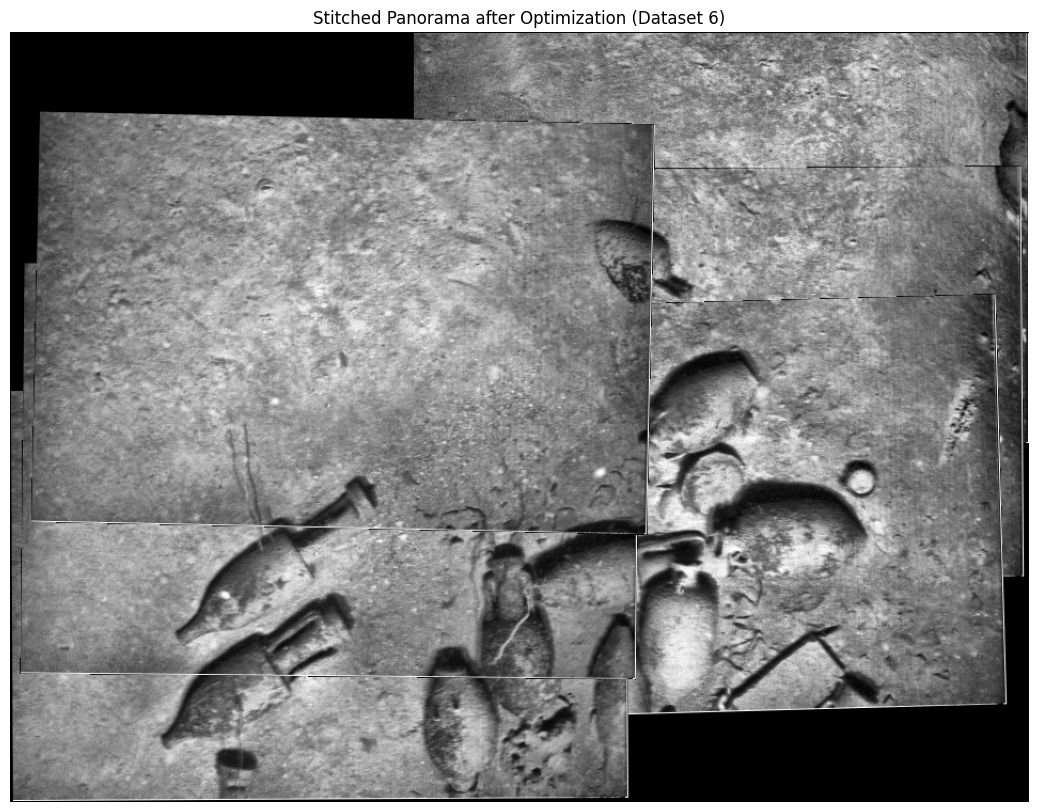

In [31]:
## Display the optimized panorama
plt.figure(figsize=(20, 10))
plt.imshow(cv2.cvtColor(panorama_optimized, cv2.COLOR_BGR2RGB))
plt.axis('off')
plt.title('Stitched Panorama after Optimization (Dataset 6)')
plt.show()

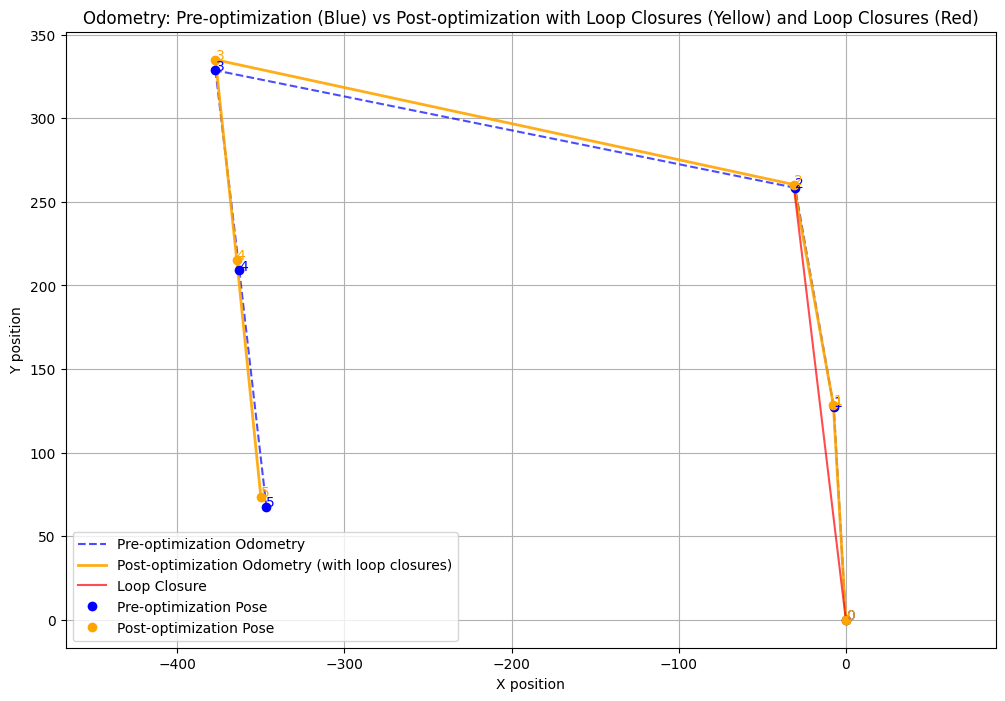

In [32]:
## Prepare pre- and post-optimization pose lists
pre_poses = camera_poses
post_poses = [result.atPose2(i) for i in range(Nimages_6)]

## Plot odometry (pre-optimization in blue, post-optimization with loop closures in yellow, loop closures in red)

plt.figure(figsize=(12, 8))
# Plot pre-optimization odometry (blue dashed)
for i in range(Nimages_6 - 1):
    pose_i = pre_poses[i]
    pose_j = pre_poses[i + 1]
    plt.plot([pose_i.x(), pose_j.x()], [pose_i.y(), pose_j.y()], 'b--', alpha=0.7, label='Pre-optimization Odometry' if i == 0 else "")
# Plot post-optimization odometry (yellow solid)
for i in range(Nimages_6 - 1):
    pose_i = post_poses[i]
    pose_j = post_poses[i + 1]
    plt.plot([pose_i.x(), pose_j.x()], [pose_i.y(), pose_j.y()], color='orange', linewidth=2, alpha=0.9, label='Post-optimization Odometry (with loop closures)' if i == 0 else "")
# Plot loop closures (red lines)
for idx, (i, j) in enumerate(connections):
    pose_i = post_poses[i]
    pose_j = post_poses[j]
    plt.plot([pose_i.x(), pose_j.x()], [pose_i.y(), pose_j.y()], 'r-', linewidth=1.5, alpha=0.7, label='Loop Closure' if idx == 0 else "")
# Plot node positions
for i in range(Nimages_6):
    plt.plot(pre_poses[i].x(), pre_poses[i].y(), 'bo', label='Pre-optimization Pose' if i == 0 else "")
    plt.plot(post_poses[i].x(), post_poses[i].y(), 'o', color='orange', label='Post-optimization Pose' if i == 0 else "")
    plt.text(pre_poses[i].x(), pre_poses[i].y(), str(i), fontsize=10, color='blue')
    plt.text(post_poses[i].x(), post_poses[i].y(), str(i), fontsize=10, color='orange')
plt.xlabel('X position')
plt.ylabel('Y position')
plt.title('Odometry: Pre-optimization (Blue) vs Post-optimization with Loop Closures (Yellow) and Loop Closures (Red)')
plt.axis('equal')
plt.grid()
plt.legend(loc='best')
plt.show()

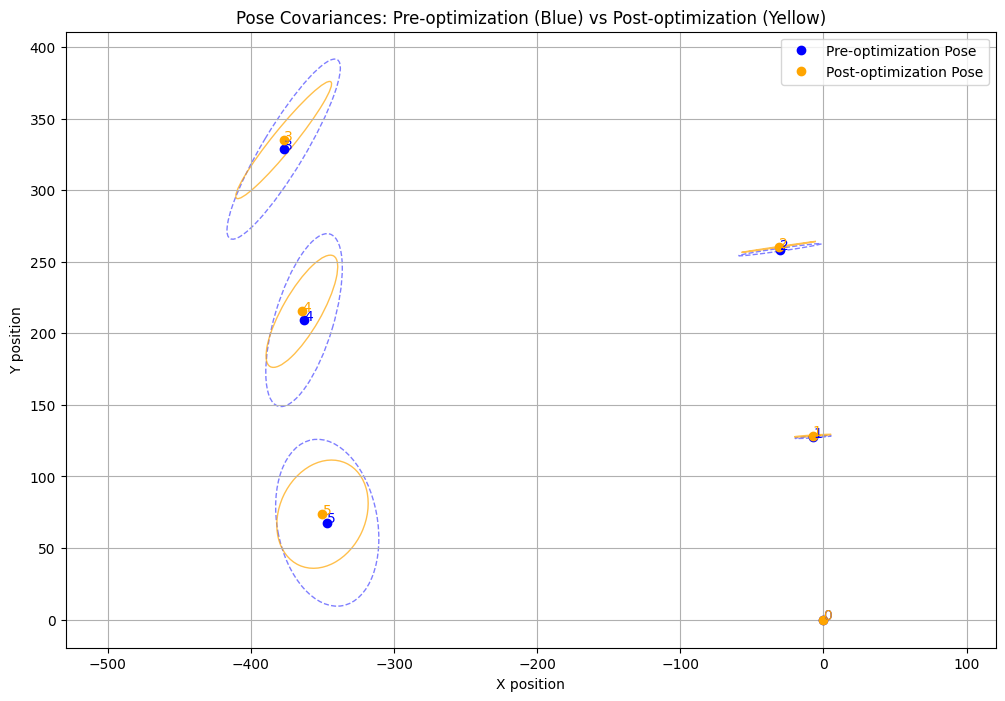

In [33]:
## Plot the pre-optimization covariances as ellipses (blue) and post-optimization covariances (yellow)
plt.figure(figsize=(12, 8))
ax = plt.gca()
# Plot pre-optimization poses and covariances (blue)
for i in range(Nimages_6):
    pose = pre_poses[i]
    plt.plot(pose.x(), pose.y(), 'bo', label='Pre-optimization Pose' if i == 0 else "")
    plt.text(pose.x(), pose.y(), str(i), fontsize=10, color='blue')
    # Covariance ellipse
    marginals = gtsam.Marginals(graph_pre, initial_estimate_pre)  # Compute marginals for pre-optimization
    covariance = marginals.marginalCovariance(i)
    eigenvalues, eigenvectors = np.linalg.eig(covariance)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    ellipse = Ellipse((pose.x(), pose.y()), width=2*np.sqrt(eigenvalues[0]), height=2*np.sqrt(eigenvalues[1]),
                      angle=angle, edgecolor='blue', facecolor='none', linestyle='--', alpha=0.5)
    ax.add_patch(ellipse)
# Plot post-optimization poses and covariances (yellow)
for i in range(Nimages_6):
    pose = post_poses[i]
    plt.plot(pose.x(), pose.y(), 'o', color='orange', label='Post-optimization Pose' if i == 0 else "")
    plt.text(pose.x(), pose.y(), str(i), fontsize=10, color='orange')
    # Covariance ellipse
    marginals = gtsam.Marginals(graph, result)  # Compute marginals for post-optimization
    covariance = marginals.marginalCovariance(i)
    eigenvalues, eigenvectors = np.linalg.eig(covariance)
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    ellipse = Ellipse((pose.x(), pose.y()), width=2*np.sqrt(eigenvalues[0]), height=2*np.sqrt(eigenvalues[1]),
                      angle=angle, edgecolor='orange', facecolor='none', linestyle='-', alpha=0.7)
    ax.add_patch(ellipse)
plt.xlabel('X position')
plt.ylabel('Y position')
plt.title('Pose Covariances: Pre-optimization (Blue) vs Post-optimization (Yellow)')
plt.axis('equal')
plt.grid()
plt.legend(loc='best')
plt.show()